<a href="https://colab.research.google.com/github/Purushoth-Archive/Practical-Exploration-/blob/main/Neural_Signal_Decoding_in_Dementia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Clinical Challenge: In early stages, Alzheimer's Disease (AD) and Frontotemporal Dementia (FTD) present with overlapping clinical symptoms, making early differential diagnosis difficult through standard observations alone.

FTD typically exhibits asymmetrical (lateralized) degeneration affecting one hemisphere more severely, whereas AD usually displays more symmetrical neural degradation.

By extracting Hemispheric Asymmetry Indices (HAI) alongside frequency band powers across 19 standard EEG channels, the pipeline quantifies these subtle left-right power disparities.

This was a personal learning project to replicate the following study:

Muhammad, F., Usmani, I. A., Aamir, M., Alduailij, M., Marzougui, M., & Nawaz, R. (2026). Interpretable AI for neural signal decoding in dementia: An EEG ensemble approach to differential diagnosis. Frontiers in Neuroinformatics. https://doi.org/10.3389/fninf.2026.1902549

In [6]:
# 1. Install required libraries
!pip install mne mne-bids xgboost openneuro-py

# 2. Download the OpenNeuro dataset (ds004504)
!openneuro-py download --dataset=ds004504


👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004504 …
📥 Checking 357 files, downloading as needed (5 concurrent downloads). 

Overall ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 5.8/5.8 GB 236.9 MB/s 0:00:00
✅ Finished downloading ds004504 (downloaded 0 files and 0 B).
 
🧠 Please enjoy your brains.
 


Building feature matrix from EEG files...
Successfully processed 88 subjects!
--- Starting 5-Fold Group Cross-Validation ---
Fold 1 Accuracy: 0.5000
Fold 2 Accuracy: 0.6111
Fold 3 Accuracy: 0.5556
Fold 4 Accuracy: 0.4118
Fold 5 Accuracy: 0.6471

Mean CV Accuracy: 0.5451 +/- 0.0833


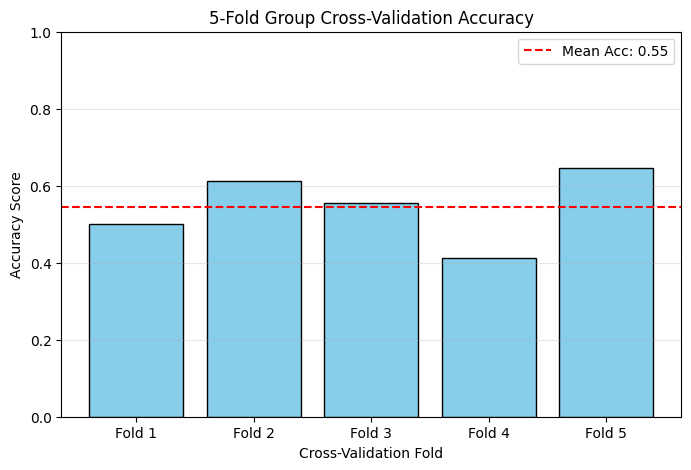

In [4]:
import os
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# ---------------------------------------------------------
# CHANNEL CONFIGURATION
# ---------------------------------------------------------
CHANNELS = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2',
            'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']

FREQ_BANDS = {
    'delta': (1.0, 4.0),
    'theta': (4.0, 8.0),
    'alpha': (8.0, 13.0),
    'beta': (13.0, 30.0),
    'gamma': (30.0, 45.0)
}

ASYMMETRY_PAIRS = [
    ('Fp1', 'Fp2'), ('F3', 'F4'), ('C3', 'C4'),
    ('P3', 'P4'), ('O1', 'O2'), ('F7', 'F8'),
    ('T3', 'T4'), ('T5', 'T6')
]

# ---------------------------------------------------------
# FEATURE EXTRACTION
# ---------------------------------------------------------
def extract_segment_features(raw_segment, sfreq):
    """
    Extracts Bandpower and Hemispheric Asymmetry Indices (HAI)
    from a single EEG time segment.
    """
    features = {}

    # 1. Compute Power Spectral Density (PSD) using Welch's method
    psd_dict = {}
    for band_name, (fmin, fmax) in FREQ_BANDS.items():
        psd = raw_segment.compute_psd(method='welch', fmin=fmin, fmax=fmax, verbose=False)
        power_vals = psd.get_data().mean(axis=-1)  # Average across time/freq bins

        for ch_idx, ch_name in enumerate(CHANNELS):
            feat_name = f"{ch_name}_{band_name}_power"
            features[feat_name] = power_vals[ch_idx]
            psd_dict[(ch_name, band_name)] = power_vals[ch_idx]

    # 2. Compute Hemispheric Asymmetry Index (HAI) for homologous pairs
    for left_ch, right_ch in ASYMMETRY_PAIRS:
        for band_name in FREQ_BANDS.keys():
            left_pwr = psd_dict[(left_ch, band_name)]
            right_pwr = psd_dict[(right_ch, band_name)]

            denom = left_pwr + right_pwr
            hai_val = (left_pwr - right_pwr) / denom if denom != 0 else 0.0
            features[f"HAI_{left_ch}_{right_ch}_{band_name}"] = hai_val

    return features

# ---------------------------------------------------------
# DATASET LOADER & FEATURE MATRIX CONSTRUCTION
# ---------------------------------------------------------
def process_subject_session(bids_root, subject_id):
    """
    Loads resting-state EEG (.set) file directly for a single subject
    and extracts bandpower + HAI features.
    """
    # Construct direct path to EEGLAB .set file in ds004504
    eeg_file_path = os.path.join(bids_root, f"sub-{subject_id}", "eeg", f"sub-{subject_id}_task-eyesclosed_eeg.set")

    if not os.path.exists(eeg_file_path):
        raise FileNotFoundError(f"File not found: {eeg_file_path}")

    # Read raw EEGLAB recording
    raw_rest = mne.io.read_raw_eeglab(eeg_file_path, preload=True, verbose=False)

    # Filter EEG: 0.5 - 45.0 Hz bandpass
    raw_rest.filter(l_freq=0.5, h_freq=45.0, verbose=False)

    # Extract baseline features
    rest_feats = extract_segment_features(raw_rest, raw_rest.info['sfreq'])
    rest_feats['subject_id'] = subject_id

    return rest_feats

def build_feature_matrix(bids_root, participants_df):
    """
    Iterates over subjects, processes resting EEG files,
    and constructs the complete feature matrix (X), targets (y), and subject groups.
    """
    records = []

    # Standardize column names to lowercase to avoid KeyErrors
    participants_df.columns = participants_df.columns.str.strip().str.lower()

    for idx, row in participants_df.iterrows():
        # Handle 3-digit zero padding (e.g., '001')
        raw_id = str(row['participant_id']).replace('sub-', '').strip()
        sub_id = raw_id.zfill(3)

        group_label = row['group'] if 'group' in row else row.get('diagnosis', 'Unknown')

        try:
            feats = process_subject_session(bids_root, sub_id)
            feats['label'] = group_label
            records.append(feats)
        except Exception:
            pass

    if len(records) == 0:
        raise RuntimeError("No subjects were processed! Check that ds004504 files exist at the specified path.")

    print(f"Successfully processed {len(records)} subjects!")
    df = pd.DataFrame(records)

    y = df['label']
    groups = df['subject_id']
    X = df.drop(columns=['label', 'subject_id'])

    return X, y, groups

# ---------------------------------------------------------
# ENSEMBLE MODEL & RFE VALIDATION
# ---------------------------------------------------------
def train_and_evaluate_ensemble(X, y, groups, n_splits=5):
    """
    Evaluates a heterogeneous ensemble (XGBoost + Random Forest) using
    GroupKFold CV with feature selection (RFE) isolated inside each fold.
    """
    gkf = GroupKFold(n_splits=n_splits)
    accuracies = []

    # Encode target labels (e.g., AD, FTD, CN -> 0, 1, 2)
    label_mapping = {label: idx for idx, label in enumerate(np.unique(y))}
    y_encoded = np.array([label_mapping[val] for val in y])

    print(f"--- Starting {n_splits}-Fold Group Cross-Validation ---")

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y_encoded, groups=groups)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

        # 1. Feature Selection: RFE reduced to top features (fit ONLY on train fold)
        n_features = min(50, X_train.shape[1])  # Adjusted for sample size stability
        base_rf = RandomForestClassifier(n_estimators=50, random_state=42)
        rfe = RFE(estimator=base_rf, n_features_to_select=n_features, step=0.1)

        X_train_rfe = rfe.fit_transform(X_train, y_train)
        X_val_rfe = rfe.transform(X_val)

        # 2. Train Base Ensemble Models
        rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
        xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.05, random_state=42)

        rf_model.fit(X_train_rfe, y_train)
        xgb_model.fit(X_train_rfe, y_train)

        # 3. Soft Voting / Probability Averaging
        rf_probs = rf_model.predict_proba(X_val_rfe)
        xgb_probs = xgb_model.predict_proba(X_val_rfe)

        ensemble_probs = (rf_probs + xgb_probs) / 2.0
        preds = np.argmax(ensemble_probs, axis=1)

        fold_acc = accuracy_score(y_val, preds)
        accuracies.append(fold_acc)
        print(f"Fold {fold + 1} Accuracy: {fold_acc:.4f}")

    print(f"\nMean CV Accuracy: {np.mean(accuracies):.4f} +/- {np.std(accuracies):.4f}")
    return accuracies

def plot_cv_results(accuracies):
    """Generates and displays accuracy graph across cross-validation folds."""
    plt.figure(figsize=(8, 5))
    folds = [f"Fold {i+1}" for i in range(len(accuracies))]

    plt.bar(folds, accuracies, color='skyblue', edgecolor='black')
    plt.axhline(y=np.mean(accuracies), color='red', linestyle='--', label=f'Mean Acc: {np.mean(accuracies):.2f}')

    plt.title('5-Fold Group Cross-Validation Accuracy')
    plt.xlabel('Cross-Validation Fold')
    plt.ylabel('Accuracy Score')
    plt.ylim(0, 1.0)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# ---------------------------------------------------------
# EXECUTION BLOCK
# ---------------------------------------------------------
if __name__ == "__main__":
    BIDS_ROOT = "./ds004504"
    PARTICIPANTS_PATH = f"{BIDS_ROOT}/participants.tsv"

    # Load clinical participant labels
    participants_df = pd.read_csv(PARTICIPANTS_PATH, sep='\t')

    # Build complete feature matrix
    print("Building feature matrix from EEG files...")
    X, y, groups = build_feature_matrix(BIDS_ROOT, participants_df)

    # Train ensemble model and produce evaluation graph
    accuracies = train_and_evaluate_ensemble(X, y, groups, n_splits=5)
    plot_cv_results(accuracies)